Using device: mps
mps
Train on 1950237 samples, validate on 216694 samples, 1905 steps per epoch
Epoch 1/6
66s - loss:  0.4853
Epoch 2/6
61s - loss:  0.1325
Epoch 3/6
62s - loss:  0.0716
Epoch 4/6
86s - loss:  0.0391
Epoch 5/6
59s - loss:  0.0216
Epoch 6/6
60s - loss:  0.0160


/opt/anaconda3/envs/cad_pointcloud/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Batch 11: Drift detected! Distance = 0.0306, Threshold = 0.0303
Batch 15: Drift detected! Distance = 0.0362, Threshold = 0.0358
Batch 42: Drift detected! Distance = 0.0536, Threshold = 0.0511
Batch 72: Drift detected! Distance = 0.0691, Threshold = 0.0690
Batch 73: Drift detected! Distance = 0.0751, Threshold = 0.0745
Batch 76: Drift detected! Distance = 0.1052, Threshold = 0.0975
Batch 93: Drift detected! Distance = 0.1000, Threshold = 0.0969
Batch 113: Drift detected! Distance = 0.0836, Threshold = 0.0787
Batch 208: Drift detected! Distance = 0.1241, Threshold = 0.0985
Batch 209: Drift detected! Distance = 0.1372, Threshold = 0.1342
Batch 260: Drift detected! Distance = 0.2640, Threshold = 0.2563
Batch 262: Drift detected! Distance = 0.2874, Threshold = 0.2835
Batch 265: Drift detected! Distance = 0.3321, Threshold = 0.3260
Batch 270: Drift detected! Distance = 1.3141, Threshold = 1.0091
Batch 271: Drift detected! Distance = 1.3352, Threshold = 1.3264
Batch 288: Drift detected! Dista

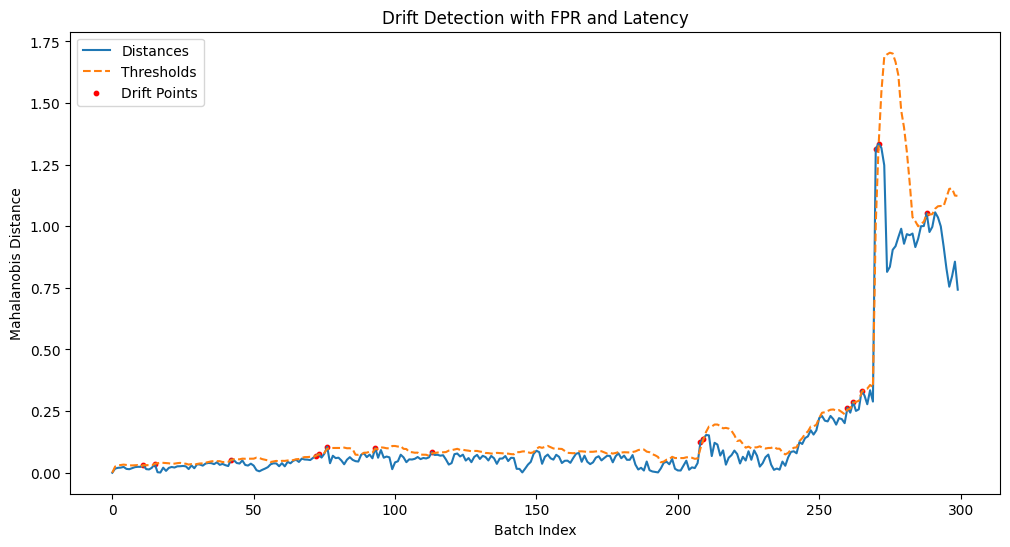

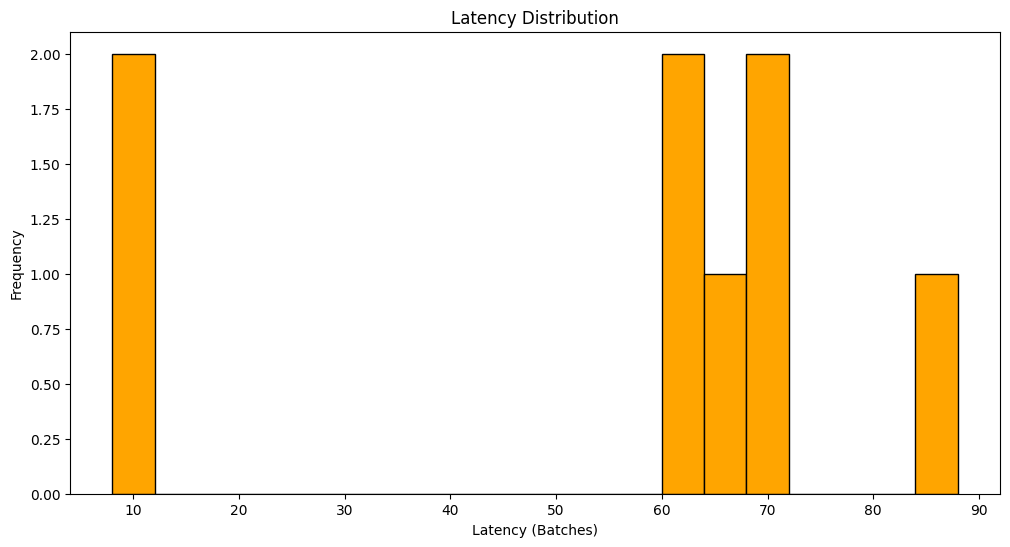

In [1]:
!pip install numpy pandas torch scikit-learn tensorflow deepctr-torch
#################################
# Import Libraries
#################################
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from deepctr_torch.inputs import SparseFeat, get_feature_names
from deepctr_torch.models import DeepFM
import matplotlib.pyplot as plt


#################################
# Utility Functions
#################################
def compute_mahalanobis_distance(mean, cov_inv, embedding):
    diff = embedding - mean
    return np.sqrt(diff.T @ cov_inv @ diff)


class DriftDetector:
    def __init__(self, embedding_dim, alpha=0.01):
        self.alpha = alpha
        self.mean = np.zeros(embedding_dim)
        self.cov = np.eye(embedding_dim)
        self.count = 0

    def update(self, embedding):
        if self.count == 0:
            self.mean = embedding
            self.cov = np.eye(len(embedding))
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding
            diff = embedding - self.mean
            self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(
                diff, diff)
        self.count += 1

    def detect_drift(self, embedding):
        return compute_mahalanobis_distance(self.mean,
                                            np.linalg.pinv(self.cov),
                                            embedding)


#################################
# Load and Preprocess Data
#################################
data = pd.read_json("experiment_1/Amazon_Fashion.jsonl", lines=True)
data = data[data["rating"] != 3]
data = data[data["timestamp"] > '2015-01-01']
data["year"] = data["timestamp"].apply(lambda x: x.year)
data["month"] = data["timestamp"].apply(lambda x: x.month)
data["day"] = data["timestamp"].apply(lambda x: x.day)
data["rating"] = data["rating"].transform(lambda x: 1 if x > 3 else 0)

data.set_index(data["timestamp"], inplace=True)
data.sort_index(inplace=True)

#################################
# Define Features and Model
#################################
sparse_features = ["parent_asin", "user_id", "year", "month", "day"]
target = ['rating']

# Label Encoding for sparse features
for feat in sparse_features:
    lbe = LabelEncoder()
    data[feat] = lbe.fit_transform(data[feat])

# Define feature columns
embedding_dim = 8
fixlen_feature_columns = [
    SparseFeat(feat, data[feat].nunique(), embedding_dim=embedding_dim)
    for feat in sparse_features
]
linear_feature_columns = fixlen_feature_columns
dnn_feature_columns = fixlen_feature_columns
feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

# Prepare model input
model_input = {name: data[name] for name in sparse_features}

# Define and compile the model
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)
model = DeepFM(linear_feature_columns, dnn_feature_columns, task='binary',
               device=device)
model.compile("adam", metrics=["AUC"], loss='binary_crossentropy')

# Train the model
history = model.fit(
    model_input,
    data[target].values,
    batch_size=1024,
    epochs=6,
    verbose=2,
    validation_split=0.1
)


# Generate embeddings and detect drift
with torch.no_grad():
    for batch_index, batch in enumerate(
            np.array_split(data[sparse_features], 300)):
        batch_input = {key: batch[key].values for key in sparse_features}
        embeddings = model.predict(batch_input)